# Modelo com Rebalanceamento e Custos de Transação 

In [1]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [4]:
basedados_ativos = Path('../../../base_dados/retornos_ativos2.csv') 
basedados_ibov = Path('../../../base_dados/retorno_ibov2.csv') 

df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).dropna()

In [5]:
metade = int(df_ativos.shape[0]/2)
print(metade)

623


In [6]:
# Metades Atvios
retornos_ativos_primeira_metade = df_ativos.iloc[0:metade]
retornos_ativos_segunda_metade = df_ativos.iloc[metade:]

# Metade ibov
retornos_ibov_primeira_metade = df_ibov.iloc[0:metade]
retornos_ibov_segunda_metade = df_ibov.iloc[metade:]




In [7]:
# ------ CRIAÇÃO DO MODELO
model = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model.ativos = pyo.RangeSet(0, len(retornos_ativos_primeira_metade.columns)-1)
model.dias = pyo.RangeSet(0, len(retornos_ativos_primeira_metade)-1)
model.retornos_ativos = pyo.Param(model.dias, model.ativos, initialize=lambda model,dia, ativo: retornos_ativos_primeira_metade.iloc[dia, ativo])    
model.retornos_ibov = pyo.Param(model.dias, initialize=lambda model,dia: retornos_ibov_primeira_metade['IBOV'].iloc[dia])

model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)

# Definindo função objetivo
# a ideia na primeira parte é reduzir o erro quadrático
def func_objetivo_1(model):
    return sum(
        (sum(model.retornos_ativos[dia, a] * model.x[a] for a in model.ativos) - model.retornos_ibov[dia])**2 for dia in model.dias
    )
model.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.minimize)


### Restrições

In [8]:

# Restrições
# soma dos pesos tem que ser igual a 1
# se y for 0 x nao é para ser 0 
#observar as dicas para, regras globais e regras individuais, 
# regra individual: peso maximo para cada ativo é 0.12
# regra global, a soma dos pesos é 1

#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model.x[a] <= model.y[a]
model.restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model.x[a] for a in model.ativos) ==1
model.soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

#Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_total(model):
    return sum(
        model.y[a] for a in model.ativos
        ) == 10
model.cardinalidade = pyo.Constraint(rule=cardinalidade_total)

opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt.options['TimeLimit'] = 60
resultado = opt.solve(model)
print("-------FIM----------")

-------FIM----------


## MOSTRANDO RESULTADO DA 1 PRIMEIRA PARTE

In [9]:
lsita_grande = []
for numero in range(len(retornos_ativos_primeira_metade.columns)):
    peso_ativo = pyo.value(model.x[numero])
    ativado = pyo.value(model.y[numero])
    lista = [peso_ativo, ativado]
    lsita_grande.append(lista)
    
final = pd.DataFrame(lsita_grande, columns=["peso_ativo","ativado"], index=retornos_ativos_primeira_metade.columns,)
print(final[final['ativado']==1])

           peso_ativo  ativado
VALE3.SA     0.173290      1.0
PETR4.SA     0.132622      1.0
B3SA3.SA     0.076207      1.0
ITSA4.SA     0.196086      1.0
ABEV3.SA     0.079672      1.0
RENT3.SA     0.095431      1.0
AXIA6.SA     0.077424      1.0
KLBN11.SA    0.071809      1.0
HYPE3.SA     0.064788      1.0
MGLU3.SA     0.032671      1.0


In [10]:
df_final = final[final['ativado']==1]
# df_final.head()
ativos_selecionados = df_final.index
retornos_carteira= retornos_ativos_primeira_metade[ativos_selecionados]

carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada
#criar a carteira equiponderada, com pesos iguais

carteira_equi = retornos_carteira.mean(axis=1)
carteira_equi = 1 + carteira_equi

C:\Users\joaon\AppData\Local\Temp\ipykernel_16064\3836110752.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_otimizado[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_16064\3836110752.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_equi[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_16064\3836110752.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_ibov[-1])
C:\Users\joaon\AppData\Local\

127.18895441841332
107.66452316000037
103.46345784474647


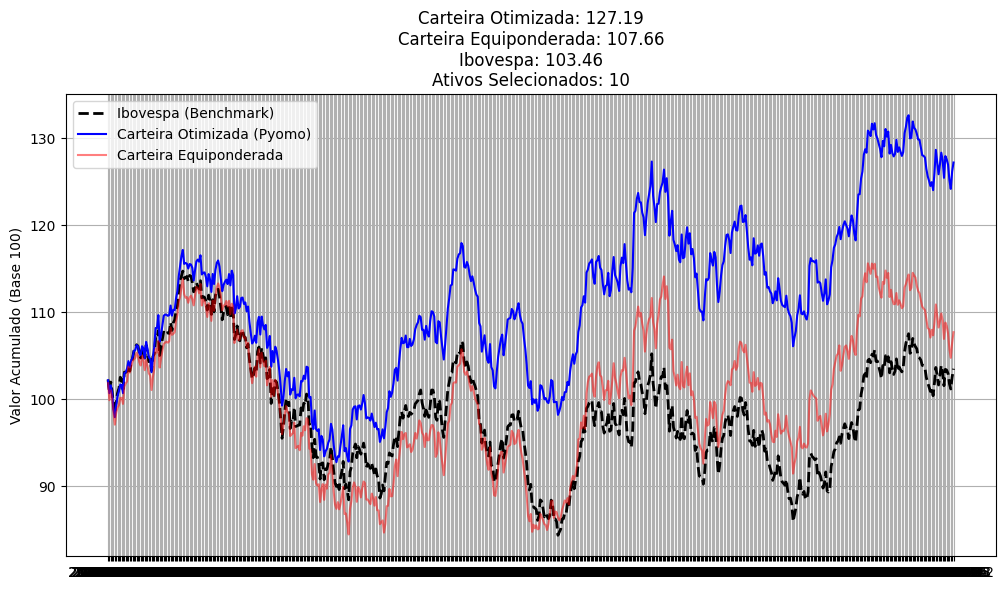

In [12]:
# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100
acum_equi = (carteira_equi).cumprod() * 100
acum_ibov = (1 + retornos_ibov_primeira_metade['IBOV']).cumprod() * 100

print(acum_otimizado[-1])
print(acum_equi[-1])
print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nCarteira Equiponderada: {acum_equi[-1]:.2f}\nIbovespa: {acum_ibov[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### -------- 2º parte -  REBALANCEAMENTO

In [13]:
pesos_anteriores = {a: pyo.value(model.x[a]) for a in model.ativos}
pesos_anteriores

{0: 0.17328964502528277,
 1: 0.0,
 2: 0.132622165861338,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.07620743475895371,
 8: 0.19608612561032235,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.07967157385589962,
 14: 0.0,
 15: 0.09543077148679063,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.0,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.07742356155277437,
 35: 0.0,
 36: 0.07180923082217484,
 37: 0.0,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.0,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.0,
 56: 0.0,
 57: 0.0,
 58: 0.06478812225085138,
 59: 0.0,
 60: 0.0,
 61: 0.0,
 62: 0.0,
 63: 0.0,
 64: 0.0,
 65: 0.0,
 66: 0.0,
 67: 0.032671368775612636,
 68: 0.0,
 69: 0.0,
 70: 0.0,
 71: 0.0,
 72: 0.0,
 73: 0.0,
 74: 0.0,
 75: 0.0,
 76: 0.0,
 77: 0.0,
 78: 0.0,
 79: 0.0,
 80: 0.0,
 81: 0.0,
 82: 0.0,
 83: 0.0,
 84: 0.0}

In [15]:
## a ideia aqui é Compra e Venda ,
## mas nao binária, ou seja, nao é 0 nao compra e 1 compra,
# é porcentagem, o quanto comprar e o quanto vender , envolvende uma custo de transação

#criando modelo novo
model_B = pyo.ConcreteModel()

model_B.ativos = pyo.RangeSet(0, len(retornos_ativos_segunda_metade.columns)-1)
model_B.dias = pyo.RangeSet(0, len(retornos_ativos_segunda_metade)-1)
model_B.ATIVOS_SEGUNDA_METADE = pyo.Param(model_B.dias, model_B.ativos, initialize=lambda model_B,dia, ativo: retornos_ativos_segunda_metade.iloc[dia, ativo])
model_B.IBOV_SEGUNDA_METADE = pyo.Param(model_B.dias, initialize = lambda model_B,dia: retornos_ibov_segunda_metade['IBOV'].iloc[dia])

#como se fosse o problema da lista de saber o Quanto a empresa deve produzir e o Quanto a empresa deve comprar o produto de outra

#Definindo variáveis de compra e venda, que serão as usadas
model_B.x = pyo.Var(model_B.ativos, bounds=(0,1)) #novos pesos 
model_B.y = pyo.Var(model_B.ativos, within=pyo.Binary) #nova cardinalidade 
model_B.compra =pyo.Var(model_B.ativos, bounds=(0,1))
model_B.venda =pyo.Var(model_B.ativos, bounds=(0,1))
custo_taxa = 0.0003 # = 0.03%
tamanho_carteira_final = 10
#OBJETIVO
def func_objetivo_2(model_B):
    #como se trata de 2 momentos, o tracking e o custo de transação
    mse_2 = sum(
        (sum(model_B.ATIVOS_SEGUNDA_METADE[dia,ativo] * model_B.x[ativo] for ativo in model_B.ativos) - model_B.IBOV_SEGUNDA_METADE[dia])**2 
        for dia in model_B.dias
        )
    custo_transacao = sum(model_B.compra[ativo] + model_B.venda[ativo] for ativo in model_B.ativos) * custo_taxa

    return mse_2 + custo_transacao
    # return mse_2

model_B.obj = pyo.Objective(rule=func_objetivo_2, sense=pyo.minimize)

#Restrições
#mais importante se a compra e venda será usada

def regra_equilibrio(model_B, ativo):
    return model_B.x[ativo] == pesos_anteriores[ativo] + model_B.compra[ativo] - model_B.venda[ativo]

model_B.regra_equilibrio = pyo.Constraint(model_B.ativos, rule=regra_equilibrio)

#restrições de soma peso 1 ; de x só ser ativado se y = 1 ; de cardinalidade 15 para y

def model_B_soma_peso_1(model_B):
    return sum(
        model_B.x[ativo] for ativo in model_B.ativos
    ) == 1
model_B.model_B_soma_peso_1 = pyo.Constraint( rule=model_B_soma_peso_1)

def model_B_y_cardinalidade(model_B):
    return sum(
        model_B.y[ativo] for ativo in model_B.ativos
    ) <= tamanho_carteira_final
model_B.model_B_y_cardinalidade = pyo.Constraint(rule = model_B_y_cardinalidade)

def model_B_x_y(model_B, ativo):
    return model_B.x[ativo] <= model_B.y[ativo]
model_B.model_B_x_y = pyo.Constraint(model_B.ativos, rule = model_B_x_y)


In [16]:
opt_B = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt_B.options['TimeLimit'] = 300
resultado = opt_B.solve(model_B)
print("-------FIM----------")

-------FIM----------


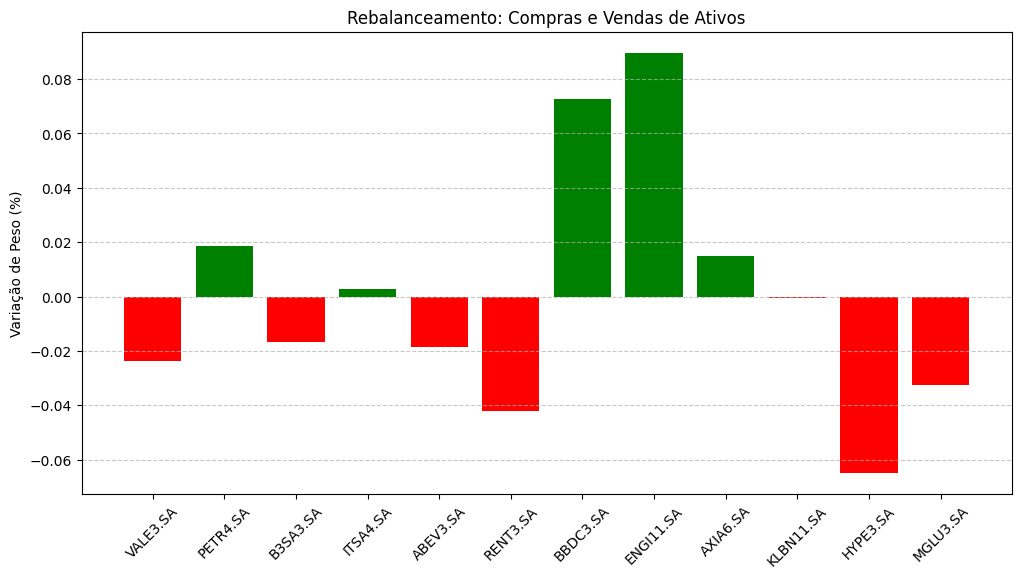

In [17]:
# Extrair os valores de compra e venda do model_B
mudancas_compra = []
mudancas_venda = []
mudancas = []
for a in range(len(retornos_ativos_segunda_metade.columns)):
    c = pyo.value(model_B.compra[a])
    v = pyo.value(model_B.venda[a])
   
    mudancas.append(c if c > 0.00001 else -v)

    
    # Se comprou, valor positivo; se vendeu, valor negativo
    mudancas_compra.append(c)
    mudancas_venda.append(v)

x_peso_final = []
y_ativado_final = []

for a in range(len(retornos_ativos_segunda_metade.columns)):
    lista_x = pyo.value(model_B.x[a])
    lista_y = pyo.value(model_B.y[a])

    x_peso_final.append(lista_x)
    y_ativado_final.append(lista_y)
    
lista_peso_anterior = df_final['peso_ativo'].tolist()
df_mudancas = pd.DataFrame({'Ativo': retornos_ativos_primeira_metade.columns,'Mudança': mudancas, 'Mudança_Compra': mudancas_compra,"Mudança_venda":mudancas_venda,'Ativado':y_ativado_final, "Peso_otimizado":x_peso_final})
# carteira_final['peso_anterior'] = lista_peso_anterior

df_mudancas2 = df_mudancas[df_mudancas['Mudança'].abs() > 0.0001] # Filtrar apenas o que mudou
carteira_final = df_mudancas[df_mudancas['Ativado']==1]


plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in df_mudancas2['Mudança']]
plt.bar(df_mudancas2['Ativo'], df_mudancas2['Mudança'], color=colors)
plt.xticks(rotation=45)
plt.title('Rebalanceamento: Compras e Vendas de Ativos')
plt.ylabel('Variação de Peso (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
print(df_final)
print(df_mudancas2)
print(carteira_final)

           peso_ativo  ativado
VALE3.SA     0.173290      1.0
PETR4.SA     0.132622      1.0
B3SA3.SA     0.076207      1.0
ITSA4.SA     0.196086      1.0
ABEV3.SA     0.079672      1.0
RENT3.SA     0.095431      1.0
AXIA6.SA     0.077424      1.0
KLBN11.SA    0.071809      1.0
HYPE3.SA     0.064788      1.0
MGLU3.SA     0.032671      1.0
        Ativo   Mudança  Mudança_Compra  Mudança_venda  Ativado  \
0    VALE3.SA -0.023594        0.000000       0.023594      1.0   
2    PETR4.SA  0.018700        0.018700       0.000000      1.0   
7    B3SA3.SA -0.016754        0.000000       0.016754      1.0   
8    ITSA4.SA  0.002955        0.002955       0.000000      1.0   
13   ABEV3.SA -0.018467        0.000000       0.018467      1.0   
15   RENT3.SA -0.042270        0.000000       0.042270      1.0   
25   BBDC3.SA  0.072838        0.072838       0.000000      1.0   
33  ENGI11.SA  0.089721        0.089721       0.000000      1.0   
34   AXIA6.SA  0.014836        0.014836       0.000000  

C:\Users\joaon\AppData\Local\Temp\ipykernel_16064\302031329.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Carteira Otimizada 2: {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"


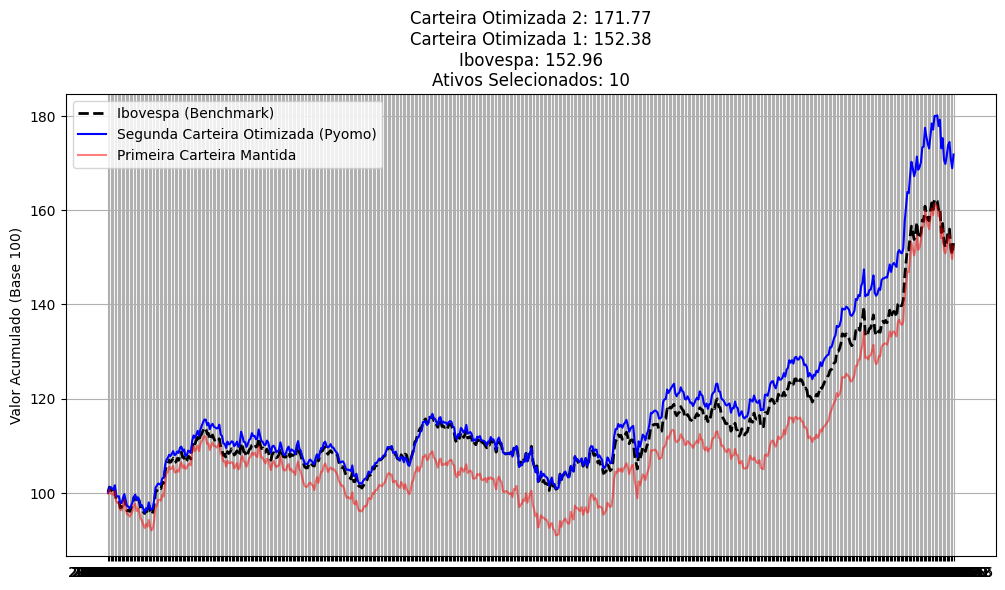

In [21]:
carteira_final2 = carteira_final['Peso_otimizado'].reset_index().drop(columns=['index']).set_index(carteira_final['Ativo'])
ativos_selecionados2 = carteira_final['Ativo'].tolist()
retornos_carteira2 = retornos_ativos_segunda_metade[ativos_selecionados2]
carteira_otimizada2 = 1 + (retornos_carteira2*carteira_final2['Peso_otimizado']).sum(axis=1)

ativos_carteira_primeira = df_final.index
retornos_carteira_primeira = retornos_ativos_segunda_metade[ativos_carteira_primeira]
carteira_primeira = 1 +(retornos_carteira_primeira*df_final['peso_ativo']).sum(axis=1)

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado2 = (carteira_otimizada2).cumprod() *100
acum_otimizado1 = (carteira_primeira).cumprod() *100
# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov2 = (1 + retornos_ibov_segunda_metade['IBOV']).cumprod() * 100

# print(acum_otimizado2[-1])
# # print(acum_equi[-1])
# print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov2, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado2, label='Segunda Carteira Otimizada (Pyomo)', color='blue')
plt.plot(acum_otimizado1, label='Primeira Carteira Mantida', color='red', alpha=0.5)

texto_titulo = f'Comparação de Performance: Index Tracking ({tamanho_carteira_final} ativos)'
texto = f"Carteira Otimizada 2: {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"

plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()